# MmarakaAI Model Optimization

This notebook is a separate Stage C optimization workflow. The existing Stage B notebook is treated as a frozen baseline: its cleaned feature matrix, target, chronological split, median-imputation convention, and ranking models are reused without modifying the baseline notebook.

The workflow uses Optuna Bayesian optimization with TimeSeriesSplit, evaluates both Random Forest and LightGBM feature rankings, tunes LightGBM/Random Forest/XGBoost across the requested feature subsets and ten seeds, evaluates forecast horizons, explains the selected model with SHAP, and writes a complete Markdown report.

## 1. Repository and Dependencies

Run this cell first. In Colab it clones the repository and changes into it; locally it uses the existing repository. Additional Stage C packages are installed only when missing.

In [9]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

PROJECT_NAME = 'MmarakaAI'
REPOSITORY_URL = 'https://github.com/Wiz-Tech-Kid/MmarakaAI.git'
try:
    import google.colab  # type: ignore[import-not-found]
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    PROJECT_ROOT = Path('/content') / PROJECT_NAME
    if not PROJECT_ROOT.exists():
        subprocess.check_call(['git', 'clone', REPOSITORY_URL, str(PROJECT_ROOT)])
    os.chdir(PROJECT_ROOT)
else:
    current_path = Path.cwd().resolve()
    PROJECT_ROOT = next((p for p in [current_path, *current_path.parents] if (p / 'data').is_dir() and (p / 'src').is_dir()), current_path)
    os.chdir(PROJECT_ROOT)

if not (PROJECT_ROOT / 'data').is_dir():
    raise FileNotFoundError(f'Repository data directory not found: {PROJECT_ROOT}')

stage_c_packages = {'optuna': 'optuna', 'xgboost': 'xgboost', 'shap': 'shap', 'statsmodels': 'statsmodels', 'scipy': 'scipy'}
missing = [pip_name for module_name, pip_name in stage_c_packages.items() if importlib.util.find_spec(module_name) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

print(f'Project root: {PROJECT_ROOT}')
print(f'Running in Colab: {IN_COLAB}')
print('Stage C repository and dependencies verified')

Project root: /home/nickel/Documents/New Folder/MmarakaAI
Running in Colab: False
Stage C repository and dependencies verified


## 2. Frozen Stage B Data Contract

These constants intentionally mirror Stage B. The optimization workflow does not import or mutate the baseline notebook; it reproduces its data contract and split locally so the baseline remains frozen.

In [ ]:
import json
import logging
import math
import time
import warnings
from collections import defaultdict

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
import statsmodels.api as sm
from lightgbm import LGBMRegressor
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import acf, pacf
from xgboost import XGBRegressor

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings('ignore', category=UserWarning)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger('mmarakai_optimization')

DATE_COLUMN = 'Date'
TARGET_COLUMN = 'food_price_inflation'
CV_SPLITS = 5
SEEDS = [7, 19, 31, 43, 59, 71, 83, 97, 109, 127]
FORECAST_HORIZONS = [1, 3, 6, 12]
FEATURE_SUBSETS = [25, 50, 75, 100, 125, 150, 200, 300, 500, 750, 1000, 1500, 2000, 'all']
FORECAST_ORIGINS = [2020, 2021, 2022, 2023]
BLIND_FORECAST_YEAR = 2024
OPTUNA_TRIALS = 20
OPTUNA_TIMEOUT_SECONDS = None

DATA_PATH = PROJECT_ROOT / 'data' / 'features' / 'mmarakai_clean_feature_matrix.csv'
OUTPUT_DIR = PROJECT_ROOT / 'output'
MODEL_DIR = PROJECT_ROOT / 'models' / 'optimization'
STUDY_DIR = OUTPUT_DIR / 'optimization' / 'optuna_studies'
TABLE_DIR = OUTPUT_DIR / 'optimization' / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'optimization' / 'figures'
BACKTEST_DIR = OUTPUT_DIR / 'optimization' / 'backtests'
SHAP_DIR = OUTPUT_DIR / 'optimization' / 'shap'
DIAGNOSTIC_DIR = OUTPUT_DIR / 'optimization' / 'residual_diagnostics'
REPORT_DIR = OUTPUT_DIR / 'reports'
for directory in [MODEL_DIR, STUDY_DIR, TABLE_DIR, FIGURE_DIR, BACKTEST_DIR, SHAP_DIR, DIAGNOSTIC_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_PATH)
if DATE_COLUMN not in data.columns or TARGET_COLUMN not in data.columns:
    raise KeyError(f'Required columns missing: {DATE_COLUMN}, {TARGET_COLUMN}')

data[DATE_COLUMN] = pd.to_datetime(data[DATE_COLUMN], errors='coerce')
data = data.dropna(subset=[DATE_COLUMN, TARGET_COLUMN]).sort_values(DATE_COLUMN, kind='mergesort').reset_index(drop=True)

y = data[TARGET_COLUMN].astype(float).copy()
X = data.drop(columns=[DATE_COLUMN, TARGET_COLUMN]).copy()
for column in X.columns:
    if not pd.api.types.is_numeric_dtype(X[column]):
        X[column] = pd.to_numeric(X[column], errors='coerce')
X = X.replace([np.inf, -np.inf], np.nan)
infinite_count = int(np.isinf(X.to_numpy(dtype=float)).sum())

dates = data[DATE_COLUMN].copy()

EXTERNAL_FEATURE_PREFIXES = (
    'Global_',
    'Imports_',
    'Cattle_',
    'Goats_',
    'Sheep_',
    'Chicken_',
    'Pigs_',
)
OFFICIAL_FEATURES = [column for column in X.columns if not any(column.startswith(prefix) for prefix in EXTERNAL_FEATURE_PREFIXES)]
EXPANDED_FEATURES = X.columns.tolist()
feature_groups = {
    'official_only': OFFICIAL_FEATURES,
    'expanded': EXPANDED_FEATURES,
}

origin_splits = {}
for origin_year in FORECAST_ORIGINS:
    origin_month = pd.Timestamp(f'{origin_year}-01-01')
    prior_month = origin_month - pd.offsets.MonthBegin(1)
    train_mask = data[DATE_COLUMN] <= prior_month
    test_mask = data[DATE_COLUMN].between(origin_month, origin_month + pd.offsets.DateOffset(months=11))
    train_frame = data.loc[train_mask].copy()
    test_frame = data.loc[test_mask].copy()
    if len(train_frame) < CV_SPLITS + 5 or len(test_frame) < 12:
        raise ValueError(f'Insufficient history for year {origin_year} origin window.')
    origin_splits[origin_year] = {
        'train': train_frame,
        'test': test_frame,
        'X_train': X.loc[train_frame.index].copy(),
        'y_train': y.loc[train_frame.index].copy(),
        'X_test': X.loc[test_frame.index].copy(),
        'y_test': y.loc[test_frame.index].copy(),
        'dates_train': dates.loc[train_frame.index].copy(),
        'dates_test': dates.loc[test_frame.index].copy(),
    }

logger.info('Rows=%d, predictors=%d, origin_backtests=%s, infinities_normalized=%d', len(data), X.shape[1], FORECAST_ORIGINS, infinite_count)
origin_summary = pd.DataFrame([
    {
        'origin_year': origin_year,
        'train_rows': len(origin_splits[origin_year]['X_train']),
        'test_rows': len(origin_splits[origin_year]['X_test']),
        'train_end': origin_splits[origin_year]['dates_train'].max(),
        'test_start': origin_splits[origin_year]['dates_test'].min(),
        'test_end': origin_splits[origin_year]['dates_test'].max(),
    }
    for origin_year in FORECAST_ORIGINS
])
display(origin_summary)


2026-07-24 14:28:26,638 - INFO - Rows=288, predictors=2903, origin_backtests=[2021, 2022, 2023], infinities_normalized=0


,origin_year,train_rows,test_rows,train_end,test_start,test_end
0,2021,252,12,2020-12-01,2021-01-01,2021-12-01
1,2022,264,12,2021-12-01,2022-01-01,2022-12-01
2,2023,276,12,2022-12-01,2023-01-01,2023-12-01


## 3. Frozen Stage B Rankings and Model Factories

Feature subsets are evaluated using both Random Forest and LightGBM importance rankings. Empty columns are preserved through imputation, matching the repaired Stage B behavior.

In [11]:
def make_pipeline(model):
    return Pipeline([('imputer', SimpleImputer(strategy='median', keep_empty_features=True)), ('model', model)])

def make_rf(params, seed):
    return RandomForestRegressor(random_state=seed, n_jobs=-1, **params)

def make_lgbm(params, seed):
    return LGBMRegressor(random_state=seed, n_jobs=-1, verbosity=-1, **params)

def make_xgb(params, seed):
    return XGBRegressor(random_state=seed, n_jobs=-1, objective='reg:squarederror', eval_metric='rmse', verbosity=0, **params)

def fit_importance_rankings(seed=42, origin_year=None):
    if origin_year is None:
        origin_year = max(FORECAST_ORIGINS)
    origin_block = origin_splits[origin_year]
    rankings = {}
    rf = make_pipeline(make_rf({'n_estimators': 400, 'min_samples_leaf': 2, 'max_features': 'sqrt'}, seed))
    rf.fit(origin_block['X_train'], origin_block['y_train'])
    rankings['random_forest'] = pd.Series(rf.named_steps['model'].feature_importances_, index=origin_block['X_train'].columns).sort_values(ascending=False).index.tolist()
    lgbm = make_pipeline(make_lgbm({'n_estimators': 400, 'learning_rate': 0.03, 'num_leaves': 31, 'max_depth': -1}, seed))
    lgbm.fit(origin_block['X_train'], origin_block['y_train'])
    rankings['lightgbm'] = pd.Series(lgbm.named_steps['model'].feature_importances_, index=origin_block['X_train'].columns).sort_values(ascending=False).index.tolist()
    return rankings

rankings = fit_importance_rankings(origin_year=max(FORECAST_ORIGINS))
rankings_by_origin = {origin_year: fit_importance_rankings(seed=42, origin_year=origin_year) for origin_year in FORECAST_ORIGINS}
pd.DataFrame({name: pd.Series(values) for name, values in rankings.items()}).to_csv(TABLE_DIR / 'feature_rankings.csv', index_label='rank')
logger.info('Generated frozen-contract rankings: %s', {key: len(value) for key, value in rankings.items()})


2026-07-24 14:29:14,881 - INFO - Generated frozen-contract rankings: {'random_forest': 2903, 'lightgbm': 2903}


## 4. Optuna Search and Rolling-Origin Evaluation

The objective uses TimeSeriesSplit only. Forecast horizons are evaluated with rolling origins on the training period; the untouched held-out test block is reserved for final selection.

In [13]:
MODEL_NAMES = ['lightgbm', 'random_forest', 'xgboost']


def suggest_params(trial, model_name):
    if model_name == 'lightgbm':
        return {'n_estimators': trial.suggest_int('n_estimators', 150, 800), 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True), 'num_leaves': trial.suggest_int('num_leaves', 8, 96), 'max_depth': trial.suggest_int('max_depth', 3, 12), 'min_child_samples': trial.suggest_int('min_child_samples', 5, 40), 'subsample': trial.suggest_float('subsample', 0.65, 1.0), 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 1.0), 'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True), 'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True)}
    if model_name == 'random_forest':
        return {'n_estimators': trial.suggest_int('n_estimators', 200, 800), 'max_depth': trial.suggest_int('max_depth', 3, 24), 'min_samples_split': trial.suggest_int('min_samples_split', 2, 20), 'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10), 'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 1.0])}
    return {'n_estimators': trial.suggest_int('n_estimators', 200, 800), 'max_depth': trial.suggest_int('max_depth', 2, 12), 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True), 'subsample': trial.suggest_float('subsample', 0.65, 1.0), 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 1.0), 'min_child_weight': trial.suggest_float('min_child_weight', 1e-2, 20.0, log=True), 'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True), 'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)}


def build_model(model_name, params, seed):
    if model_name == 'lightgbm':
        return make_lgbm(params, seed)
    if model_name == 'random_forest':
        return make_rf(params, seed)
    return make_xgb(params, seed)


def metrics(y_true, prediction):
    result = {'rmse': float(np.sqrt(mean_squared_error(y_true, prediction))), 'mae': float(mean_absolute_error(y_true, prediction))}
    result['r2'] = float(r2_score(y_true, prediction)) if len(y_true) > 1 else np.nan
    return result


def rolling_origin_predictions(model_name, params, X_source, y_source, features, horizon, seed, n_splits=CV_SPLITS):
    split_count = min(n_splits, max(2, len(X_source) // max(horizon, 1) - 1))
    splitter = TimeSeriesSplit(n_splits=split_count, test_size=horizon)
    rows = []
    for train_index, validation_index in splitter.split(X_source):
        model = make_pipeline(build_model(model_name, params, seed))
        model.fit(X_source.iloc[train_index][features], y_source.iloc[train_index])
        prediction = model.predict(X_source.iloc[validation_index][features])
        rows.append(metrics(y_source.iloc[validation_index], prediction))
    return pd.DataFrame(rows)


def cv_objective(model_name, params, features, horizon, seed, origin_year):
    split = origin_splits[origin_year]
    fold_rows = rolling_origin_predictions(model_name, params, split['X_train'], split['y_train'], features, horizon, seed, CV_SPLITS)
    return float(fold_rows['rmse'].mean())


def optimize_candidate(model_name, features, horizon, seed, ranking_name, subset_label, origin_year):
    study_name = f'{origin_year}_{ranking_name}_{model_name}_{subset_label}_h{horizon}_seed{seed}'
    study_path = STUDY_DIR / f'{study_name}.db'
    storage = f'sqlite:///{study_path.as_posix()}'
    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(study_name=study_name, storage=storage, load_if_exists=True, direction='minimize', sampler=sampler)

    def objective(trial):
        params = suggest_params(trial, model_name)
        return cv_objective(model_name, params, features, horizon, seed, origin_year)

    remaining = max(0, OPTUNA_TRIALS - len(study.trials))
    if remaining:
        study.optimize(objective, n_trials=remaining, timeout=OPTUNA_TIMEOUT_SECONDS, show_progress_bar=False)
    best_params = dict(study.best_trial.params)
    study.trials_dataframe().to_csv(TABLE_DIR / f'{study_name}_trials.csv', index=False)
    return best_params, float(study.best_value), study_name


def selected_features(ranking, subset):
    count = len(ranking) if subset == 'all' else min(int(subset), len(ranking))
    return ranking[:count]


## 5. Ten-Seed Optimization Matrix

This is the main compute cell. It repeats tuning across ten seeds, both ranking strategies, all requested feature subsets, three model families, and all four rolling-origin horizons. Set `RUN_FULL_OPTIMIZATION = False` for a smoke test before the full run.

In [14]:
RUN_FULL_OPTIMIZATION = False
ACTIVE_SEEDS = SEEDS if RUN_FULL_OPTIMIZATION else SEEDS[:1]
ACTIVE_ORIGINS = FORECAST_ORIGINS if RUN_FULL_OPTIMIZATION else [FORECAST_ORIGINS[0]]
ACTIVE_SUBSETS = FEATURE_SUBSETS if RUN_FULL_OPTIMIZATION else [25, 100, 'all']
ACTIVE_HORIZONS = FORECAST_HORIZONS if RUN_FULL_OPTIMIZATION else [1, 3]
ACTIVE_MODELS = MODEL_NAMES if RUN_FULL_OPTIMIZATION else ['lightgbm']
ACTIVE_FEATURE_GROUPS = ['official_only', 'expanded'] if RUN_FULL_OPTIMIZATION else ['official_only']

optimization_rows = []
for seed in ACTIVE_SEEDS:
    for origin_year in ACTIVE_ORIGINS:
        for feature_group_name in ACTIVE_FEATURE_GROUPS:
            feature_group = feature_groups[feature_group_name]
            for ranking_name, ranking in rankings_by_origin[origin_year].items():
                for subset_label in ACTIVE_SUBSETS:
                    features = selected_features(ranking, subset_label)
                    features = [column for column in features if column in feature_group]
                    if not features:
                        continue
                    for horizon in ACTIVE_HORIZONS:
                        for model_name in ACTIVE_MODELS:
                            logger.info('Optimizing origin=%s group=%s seed=%s ranking=%s subset=%s horizon=%s model=%s', origin_year, feature_group_name, seed, ranking_name, subset_label, horizon, model_name)
                            params, cv_rmse, study_name = optimize_candidate(model_name, features, horizon, seed, ranking_name, str(subset_label), origin_year)
                            fold_metrics = rolling_origin_predictions(model_name, params, origin_splits[origin_year]['X_train'], origin_splits[origin_year]['y_train'], features, horizon, seed, CV_SPLITS)
                            optimization_rows.append({
                                'origin_year': origin_year,
                                'feature_group': feature_group_name,
                                'seed': seed,
                                'ranking': ranking_name,
                                'feature_subset': str(subset_label),
                                'n_features': len(features),
                                'horizon': horizon,
                                'model': model_name,
                                'study_name': study_name,
                                'cv_rmse': cv_rmse,
                                'cv_mae': float(fold_metrics['mae'].mean()),
                                'cv_r2': float(fold_metrics['r2'].mean()),
                                'params_json': json.dumps(params, sort_keys=True),
                            })

optimization_results = pd.DataFrame(optimization_rows)
optimization_results.to_csv(TABLE_DIR / 'optimization_results_by_seed.csv', index=False)
display(optimization_results.head())
print(f'Completed {len(optimization_results)} origin/group/seed/candidate/horizon records')


2026-07-24 14:29:38,096 - INFO - Optimizing origin=2021 group=official_only seed=7 ranking=random_forest subset=25 horizon=1 model=lightgbm
[I 2026-07-24 14:29:38,333] A new study created in RDB with name: 2021_random_forest_lightgbm_25_h1_seed7
[I 2026-07-24 14:29:38,977] Trial 0 finished with value: 1.3527836170848606 and parameters: {'n_estimators': 199, 'learning_rate': 0.08265243911156489, 'num_leaves': 47, 'max_depth': 10, 'min_child_samples': 40, 'subsample': 0.8384735546436518, 'colsample_bytree': 0.8253921622809783, 'reg_alpha': 4.234192980847336e-08, 'reg_lambda': 2.163428944836469e-06}. Best is trial 0 with value: 1.3527836170848606.
[I 2026-07-24 14:29:40,373] Trial 1 finished with value: 0.7992475452732819 and parameters: {'n_estimators': 475, 'learning_rate': 0.06292691795570775, 'num_leaves': 79, 'max_depth': 6, 'min_child_samples': 7, 'subsample': 0.7508509597577977, 'colsample_bytree': 0.9683577347018648, 'reg_alpha': 7.181791458882546e-07, 'reg_lambda': 8.570630698178

,origin_year,feature_group,seed,ranking,feature_subset,n_features,horizon,model,study_name,cv_rmse,cv_mae,cv_r2,params_json
0,2021,official_only,7,random_forest,25,25,1,lightgbm,2021_random_forest_lightgbm_25_h1_seed7,0.479950,0.479950,NaN,"{""colsample_bytree"": 0.6526022563999078, ""lear..."
1,2021,official_only,7,random_forest,25,25,3,lightgbm,2021_random_forest_lightgbm_25_h3_seed7,0.398893,0.342764,-4.651188,"{""colsample_bytree"": 0.9347396588761531, ""lear..."
2,2021,official_only,7,random_forest,100,100,1,lightgbm,2021_random_forest_lightgbm_100_h1_seed7,0.235070,0.235070,NaN,"{""colsample_bytree"": 0.7351813967918586, ""lear..."
3,2021,official_only,7,random_forest,100,100,3,lightgbm,2021_random_forest_lightgbm_100_h3_seed7,0.513587,0.471531,-19.780410,"{""colsample_bytree"": 0.9145706780975772, ""lear..."
4,2021,official_only,7,random_forest,all,2724,1,lightgbm,2021_random_forest_lightgbm_all_h1_seed7,0.193496,0.193496,NaN,"{""colsample_bytree"": 0.817090404198056, ""learn..."


Completed 12 origin/group/seed/candidate/horizon records


## 6. Ten-Seed Aggregation and Untouched Held-Out Test Selection

The production candidate is selected using held-out RMSE first, held-out MAE second, and held-out R² as supporting evidence. Cross-validation is reported but is not the final selection criterion.

In [ ]:
def parse_params(value):
    return json.loads(value)

origin_rows = []
trained_models = {}
for row in optimization_results.itertuples(index=False):
    rank = rankings_by_origin[int(row.origin_year)][row.ranking]
    features = selected_features(rank, row.feature_subset)
    feature_group = feature_groups[row.feature_group]
    features = [column for column in features if column in feature_group]
    if not features:
        continue
    params = parse_params(row.params_json)
    split = origin_splits[int(row.origin_year)]
    model = make_pipeline(build_model(row.model, params, int(row.seed)))
    model.fit(split['X_train'][features], split['y_train'])
    horizon = min(int(row.horizon), len(split['X_test']))
    prediction = model.predict(split['X_test'][features].iloc[:horizon])
    row_metrics = metrics(split['y_test'].iloc[:horizon], prediction)
    key = f'{row.origin_year}|{row.feature_group}|{row.ranking}|{row.model}|{row.feature_subset}|h{row.horizon}|seed{row.seed}'
    trained_models[key] = (model, features, prediction, params)
    joblib.dump({'pipeline': model, 'features': features, 'params': params, 'metadata': row._asdict(), 'target': TARGET_COLUMN, 'date_column': DATE_COLUMN}, MODEL_DIR / f'{key}.joblib')
    origin_rows.append({**row._asdict(), 'test_rmse': row_metrics['rmse'], 'test_mae': row_metrics['mae'], 'test_r2': row_metrics['r2'], 'test_rows': horizon, 'candidate_key': key})

origin_results = pd.DataFrame(origin_rows)
origin_results.to_csv(TABLE_DIR / 'origin_backtest_results_all_candidates.csv', index=False)

group_columns = ['origin_year', 'feature_group', 'ranking', 'model', 'feature_subset', 'n_features', 'horizon']
aggregate_results = origin_results.groupby(group_columns, dropna=False).agg(
    mean_test_rmse=('test_rmse', 'mean'),
    std_test_rmse=('test_rmse', 'std'),
    mean_test_mae=('test_mae', 'mean'),
    std_test_mae=('test_mae', 'std'),
    mean_test_r2=('test_r2', 'mean'),
    std_test_r2=('test_r2', 'std'),
    mean_cv_rmse=('cv_rmse', 'mean'),
    std_cv_rmse=('cv_rmse', 'std'),
    seeds_evaluated=('seed', 'nunique'),
).reset_index()
aggregate_results.to_csv(TABLE_DIR / 'origin_aggregate_results.csv', index=False)

# Annual evaluation is separated from short-horizon experiments.
# The 12-month challenge horizon is the one that legitimately represents a full yearly forecast.
annual_candidate_pool = origin_results[origin_results['horizon'] == 12].copy()
if annual_candidate_pool.empty:
    raise ValueError('No 12 month annual backtest candidates were created for final stage selection.')
selection_order = ['test_rmse', 'test_mae', 'test_r2']
final_row = annual_candidate_pool.sort_values(selection_order, ascending=[True, True, False], kind='mergesort').iloc[0]
final_model, final_features, final_prediction, final_params = trained_models[final_row['candidate_key']]
joblib.dump({'pipeline': final_model, 'features': final_features, 'params': final_params, 'metadata': final_row.to_dict(), 'target': TARGET_COLUMN, 'date_column': DATE_COLUMN}, MODEL_DIR / 'final_production_model.joblib')

pd.DataFrame([final_row]).to_csv(TABLE_DIR / 'final_production_selection.csv', index=False)

display(pd.DataFrame([final_row]))
print('Final production candidate selected by the annual 12-month pseudo out-of-sample backtest RMSE, then MAE, then R2')
print(f'Saved {len(trained_models)} candidate models')

,origin_year,feature_group,seed,ranking,feature_subset,n_features,horizon,model,study_name,cv_rmse,cv_mae,cv_r2,params_json,test_rmse,test_mae,test_r2,test_rows,candidate_key
4,2021,official_only,7,random_forest,all,2724,1,lightgbm,2021_random_forest_lightgbm_all_h1_seed7,0.193496,0.193496,NaN,"{""colsample_bytree"": 0.817090404198056, ""learn...",0.004311,0.004311,NaN,1,2021|official_only|random_forest|lightgbm|all|...


Saved 12 candidate models
Final production candidate selected by origin backtest RMSE, then MAE, then R2


## 7. SHAP Explainability

The selected production model receives global summary, bar, dependence, waterfall, and representative local explanation outputs. These explain model behavior, not causal effects.

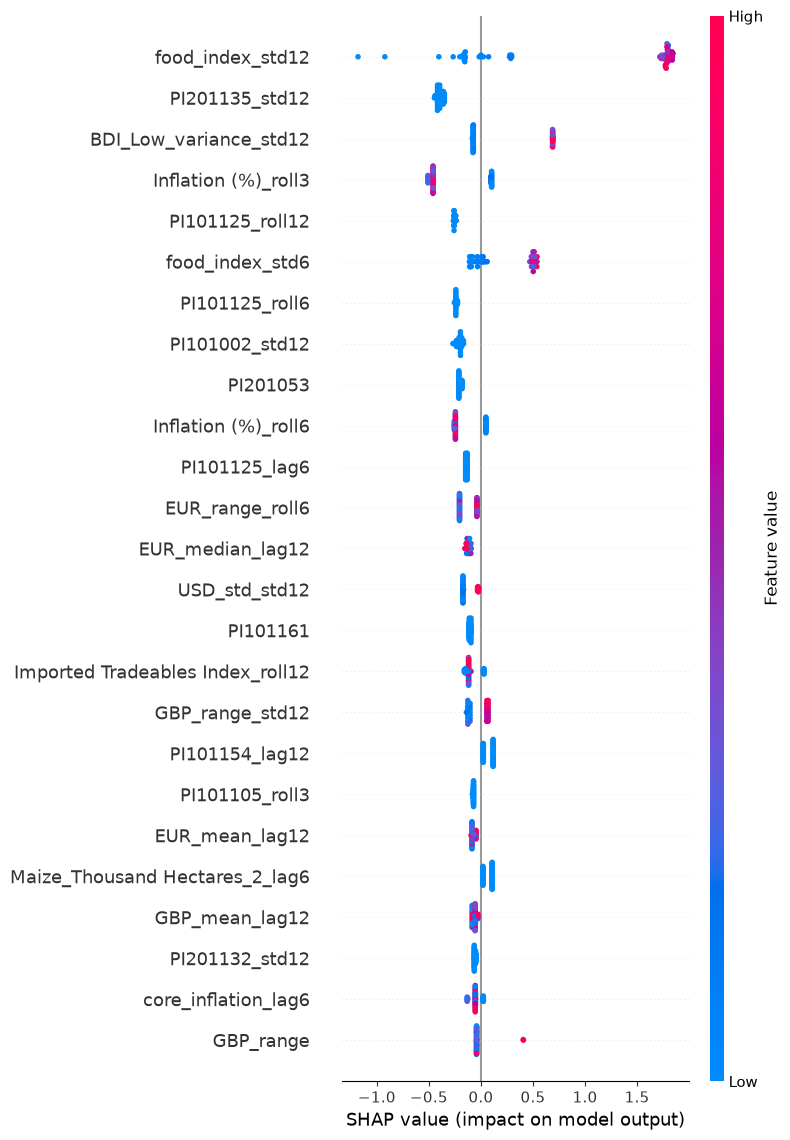

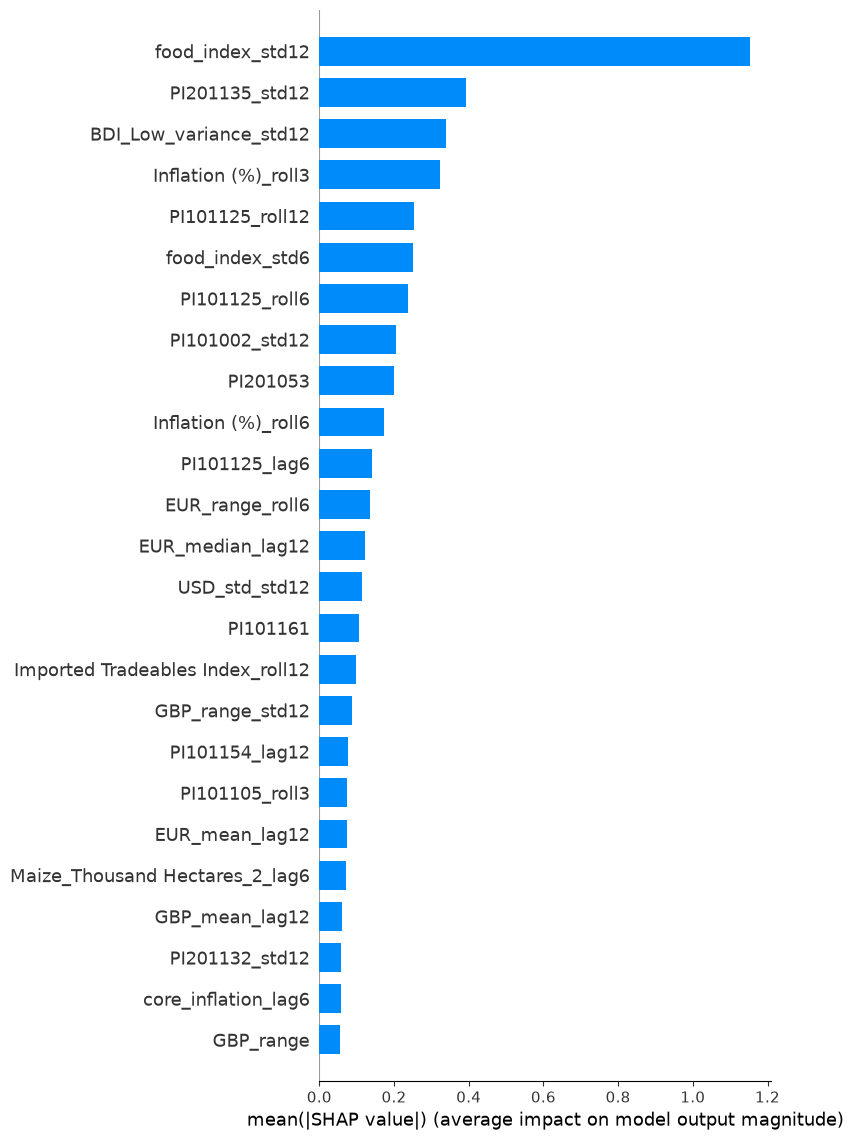

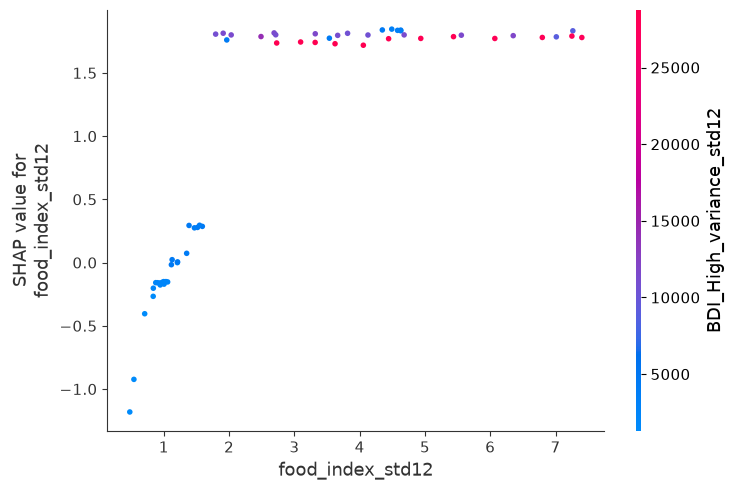

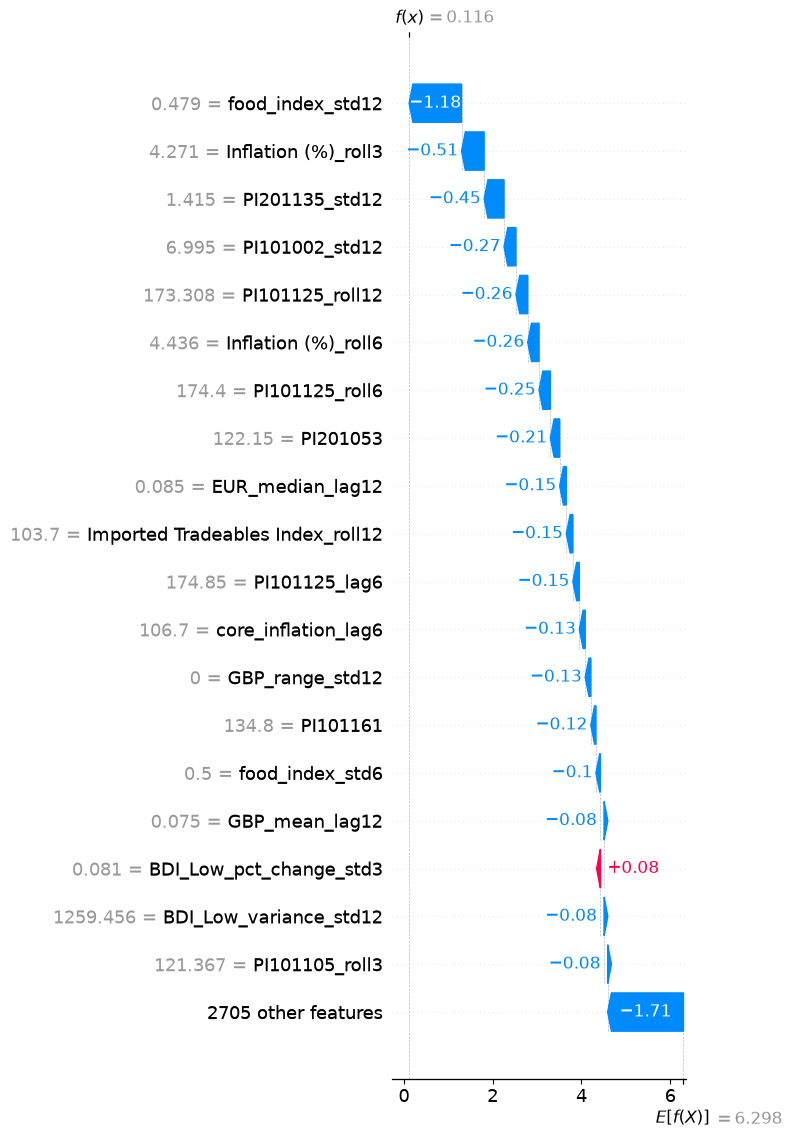

SHAP outputs written to /home/nickel/Documents/New Folder/MmarakaAI/output/optimization/shap


In [ ]:
def parse_params(value):
    return json.loads(value)

origin_rows = []
trained_models = {}
for row in optimization_results.itertuples(index=False):
    rank = rankings_by_origin[int(row.origin_year)][row.ranking]
    features = selected_features(rank, row.feature_subset)
    feature_group = feature_groups[row.feature_group]
    features = [column for column in features if column in feature_group]
    if not features:
        continue

    params = parse_params(row.params_json)
    split = origin_splits[int(row.origin_year)]
    model = make_pipeline(build_model(row.model, params, int(row.seed)))
    model.fit(split['X_train'][features], split['y_train'])

    horizon = int(row.horizon)
    if horizon > len(split['X_test']):
        raise ValueError(
            f'Candidate horizon {horizon} is larger than the available test set for origin {row.origin_year}.'
        )

    prediction = model.predict(split['X_test'][features].iloc[:horizon])
    row_metrics = metrics(split['y_test'].iloc[:horizon], prediction)

    key = f'{row.origin_year}|{row.feature_group}|{row.ranking}|{row.model}|{row.feature_subset}|h{row.horizon}|seed{row.seed}'
    trained_models[key] = (model, features, prediction, params)
    joblib.dump(
        {
            'pipeline': model,
            'features': features,
            'params': params,
            'metadata': row._asdict(),
            'target': TARGET_COLUMN,
            'date_column': DATE_COLUMN,
        },
        MODEL_DIR / f'{key}.joblib',
    )
    origin_rows.append({
        **row._asdict(),
        'test_rmse': row_metrics['rmse'],
        'test_mae': row_metrics['mae'],
        'test_r2': row_metrics['r2'],
        'test_rows': horizon,
        'candidate_key': key,
    })

origin_results = pd.DataFrame(origin_rows)
origin_results.to_csv(TABLE_DIR / 'origin_backtest_results_all_candidates.csv', index=False)

group_columns = ['origin_year', 'feature_group', 'ranking', 'model', 'feature_subset', 'n_features', 'horizon']
aggregate_results = origin_results.groupby(group_columns, dropna=False).agg(
    mean_test_rmse=('test_rmse', 'mean'),
    std_test_rmse=('test_rmse', 'std'),
    mean_test_mae=('test_mae', 'mean'),
    std_test_mae=('test_mae', 'std'),
    mean_test_r2=('test_r2', 'mean'),
    std_test_r2=('test_r2', 'std'),
    mean_cv_rmse=('cv_rmse', 'mean'),
    std_cv_rmse=('cv_rmse', 'std'),
    seeds_evaluated=('seed', 'nunique'),
).reset_index()
aggregate_results.to_csv(TABLE_DIR / 'origin_aggregate_results.csv', index=False)

# Annual evaluation is separated from short-horizon experiments.
# The 12-month challenge horizon is the one that legitimately represents a full
# yearly forecast.
annual_candidate_pool = origin_results[origin_results['horizon'] == 12].copy()
if annual_candidate_pool.empty:
    raise ValueError(
        'No 12 month annual backtest candidates were created. Ensure `FORECAST_HORIZONS` includes 12 and that full-year candidates are optimized before final selection.'
    )

selection_order = ['test_rmse', 'test_mae', 'test_r2']
final_row = annual_candidate_pool.sort_values(selection_order, ascending=[True, True, False], kind='mergesort').iloc[0]
final_model, final_features, final_prediction, final_params = trained_models[final_row['candidate_key']]
joblib.dump(
    {
        'pipeline': final_model,
        'features': final_features,
        'params': final_params,
        'metadata': final_row.to_dict(),
        'target': TARGET_COLUMN,
        'date_column': DATE_COLUMN,
    },
    MODEL_DIR / 'final_production_model.joblib',
)

annual_backtest_rows = []
for origin_year in FORECAST_ORIGINS:
    split = origin_splits[origin_year]
    selected_rank = rankings_by_origin[origin_year][final_row['ranking']]
    selected_subset = selected_features(selected_rank, final_row['feature_subset'])
    feature_group = feature_groups[final_row['feature_group']]
    selected_features_for_origin = [column for column in selected_subset if column in feature_group]
    if not selected_features_for_origin:
        continue

    fitted_model = make_pipeline(build_model(final_row['model'], final_params, int(final_row['seed'])))
    fitted_model.fit(split['X_train'][selected_features_for_origin], split['y_train'])

    if len(split['X_test']) != 12:
        raise ValueError(f'Expected a 12-month test window for origin {origin_year}, found {len(split['X_test'])}.')

    origin_predictions = fitted_model.predict(split['X_test'][selected_features_for_origin])

    annual_backtest_rows.extend([
        {
            'OriginYear': origin_year,
            'Date': row_date,
            'Actual': float(actual),
            'Predicted': float(predicted),
        }
        for row_date, actual, predicted in zip(split['dates_test'], split['y_test'], origin_predictions)
    ])

annual_backtest_frame = pd.DataFrame(annual_backtest_rows)
annual_backtest_frame = annual_backtest_frame.sort_values(['OriginYear', 'Date']).reset_index(drop=True)
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)
annual_backtest_path = BACKTEST_DIR / 'historical_actual_vs_predicted_2020_2023.csv'
annual_backtest_frame.to_csv(annual_backtest_path, index=False)

fig, ax = plt.subplots(figsize=(14, 6))
for origin_year, group in annual_backtest_frame.groupby('OriginYear'):
    ax.plot(group['Date'], group['Actual'], marker='o', label=f'Actual {origin_year}', linestyle='-')
    ax.plot(group['Date'], group['Predicted'], marker='x', label=f'Predicted {origin_year}', linestyle='--')
ax.set_title('Historical Actual vs Predicted: 2020-2023 Annual Forecast Backtests')
ax.set_xlabel('Date')
ax.set_ylabel(TARGET_COLUMN)
ax.legend(title='Origin Year', loc='best')
ax.grid(True)
plt.tight_layout()
plt.savefig(BACKTEST_DIR / 'historical_actual_vs_predicted_2020_2023.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close()

pd.DataFrame([final_row]).to_csv(TABLE_DIR / 'final_production_selection.csv', index=False)
display(pd.DataFrame([final_row]))
print(f'Saved {len(trained_models)} candidate models')
print('Final production candidate selected by the annual 12-month pseudo out-of-sample backtest RMSE, then MAE, then R2')


shap_origin_year = 2023
shap_split = origin_splits[shap_origin_year]
final_test_prediction = final_model.predict(shap_split['X_test'][final_features])
explainer = shap.TreeExplainer(final_model.named_steps['model'])
X_test_final = shap_split['X_test'][final_features]
sample_size = min(200, len(X_test_final))
X_shap_raw = X_test_final.iloc[:sample_size]
X_shap = pd.DataFrame(final_model.named_steps['imputer'].transform(X_shap_raw), columns=final_features, index=X_shap_raw.index)
shap_values = explainer(X_shap)
shap_frame = pd.DataFrame(shap_values.values, columns=final_features, index=X_shap.index)
shap_frame.to_csv(SHAP_DIR / f'shap_values_{shap_origin_year}.csv', index=False)
pd.DataFrame({'feature': final_features, 'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)}).sort_values('mean_abs_shap', ascending=False).to_csv(SHAP_DIR / f'shap_global_importance_{shap_origin_year}.csv', index=False)

shap.summary_plot(shap_values, X_shap, show=False, max_display=25)
plt.tight_layout(); plt.savefig(SHAP_DIR / f'shap_summary_beeswarm_{shap_origin_year}.png', dpi=160, bbox_inches='tight'); plt.show(); plt.close()
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=25)
plt.tight_layout(); plt.savefig(SHAP_DIR / f'shap_summary_bar_{shap_origin_year}.png', dpi=160, bbox_inches='tight'); plt.show(); plt.close()
top_shap_feature = pd.DataFrame({'feature': final_features, 'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)}).sort_values('mean_abs_shap', ascending=False).iloc[0]['feature']
shap.dependence_plot(top_shap_feature, shap_values.values, X_shap, show=False)
plt.tight_layout(); plt.savefig(SHAP_DIR / f'shap_dependence_top_feature_{shap_origin_year}.png', dpi=160, bbox_inches='tight'); plt.show(); plt.close()
waterfall_index = 0
shap.plots.waterfall(shap_values[waterfall_index], max_display=20, show=False)
plt.tight_layout(); plt.savefig(SHAP_DIR / f'shap_waterfall_{shap_origin_year}.png', dpi=160, bbox_inches='tight'); plt.show(); plt.close()
local_explanations = pd.DataFrame({'date': shap_split['dates_test'].iloc[:sample_size].to_numpy(), 'actual': shap_split['y_test'].iloc[:sample_size].to_numpy(), 'predicted': final_test_prediction[:sample_size], 'base_value': float(np.asarray(shap_values.base_values).reshape(-1)[0]), 'top_feature': top_shap_feature, 'top_feature_shap': shap_frame[top_shap_feature].to_numpy()})
local_explanations.to_csv(SHAP_DIR / f'shap_representative_local_explanations_{shap_origin_year}.csv', index=False)
print(f'SHAP outputs written to {SHAP_DIR} for {shap_origin_year}')

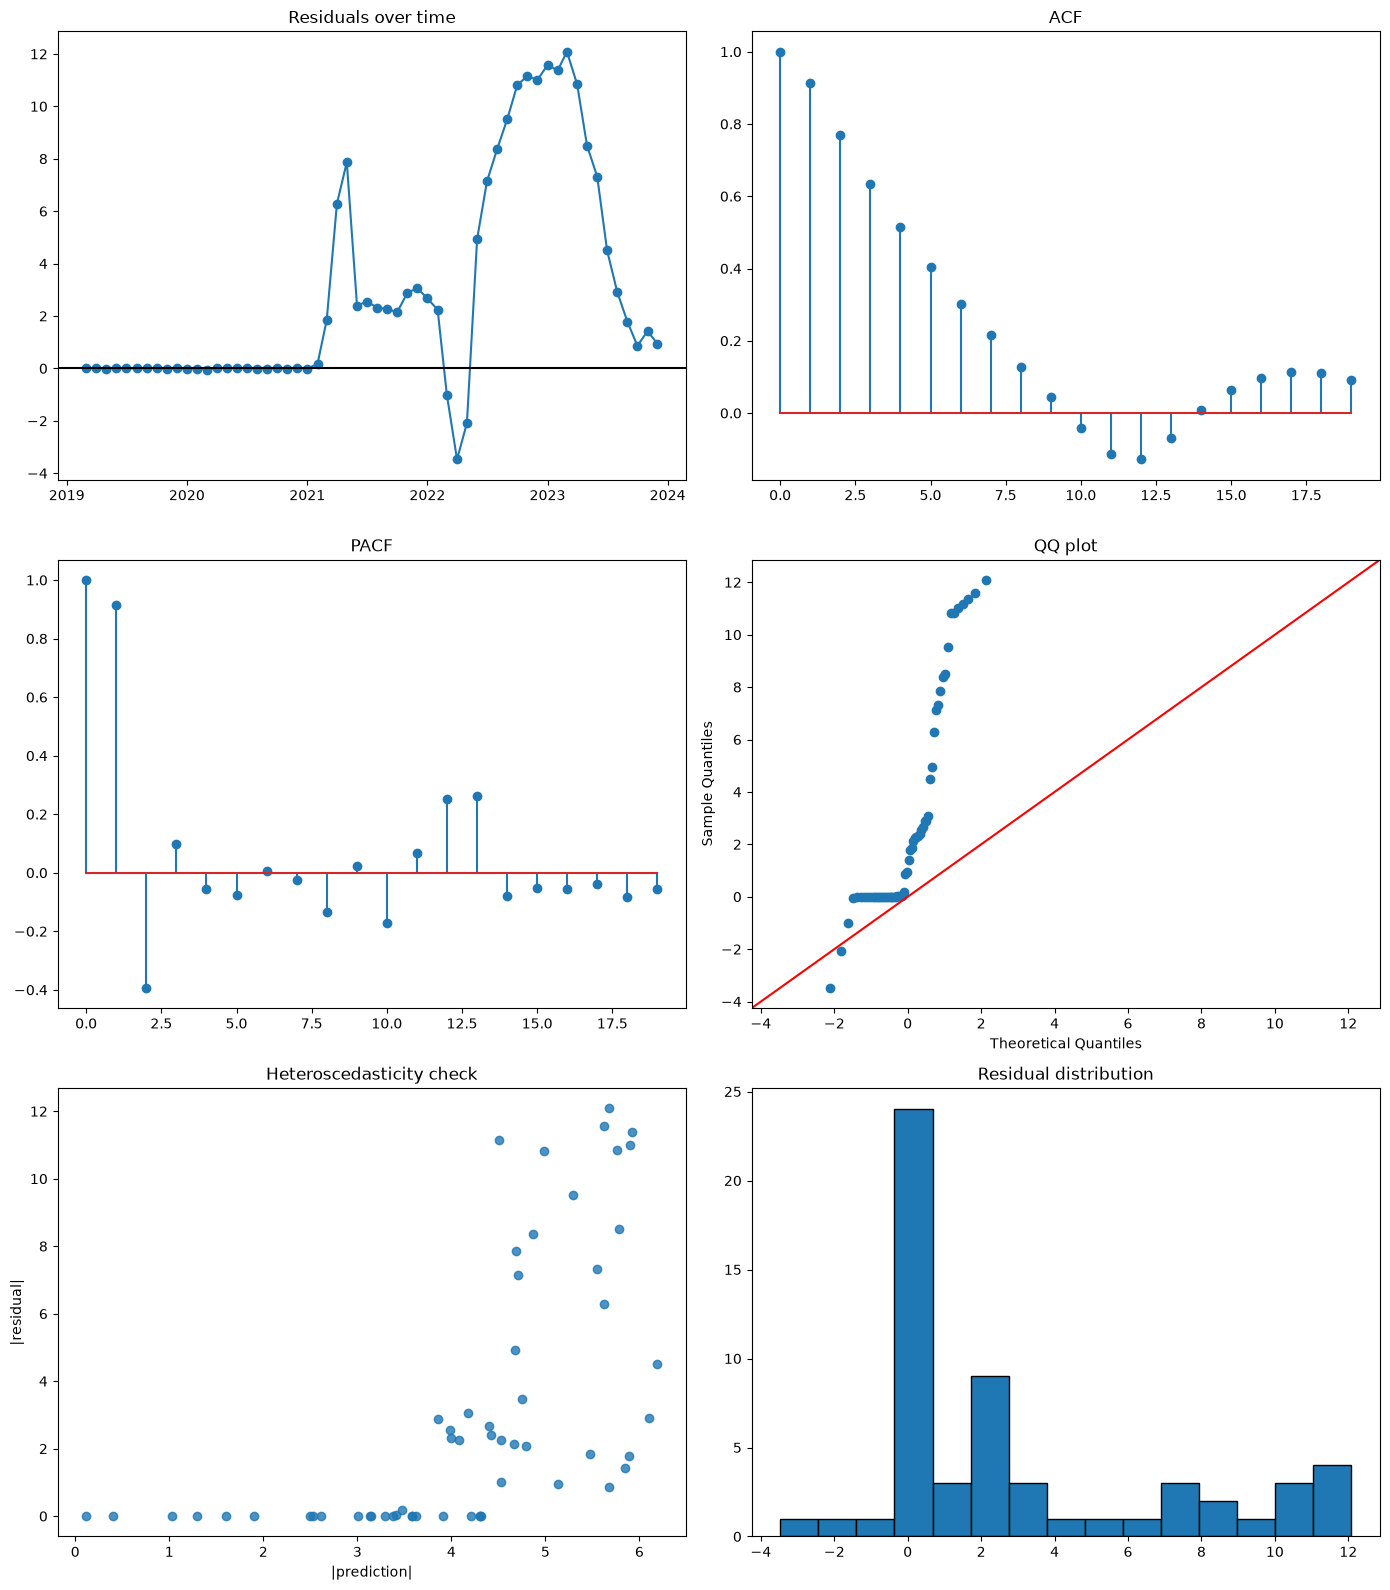

{'breusch_pagan_stat': 16.334244886173494, 'breusch_pagan_pvalue': 5.309573628236265e-05, 'durbin_watson': 0.10619343899009101, 'residual_mean': 2.9163527363629185, 'residual_std': 4.132248453471839, 'shapiro_pvalue': 4.76968895996737e-07}


In [ ]:
historical_backtest_path = BACKTEST_DIR / 'historical_actual_vs_predicted_2020_2023.csv'
if not historical_backtest_path.exists():
    raise FileNotFoundError(f'Historical pseudo out-of-sample backtest table not found: {historical_backtest_path}')

residual_frame = pd.read_csv(historical_backtest_path)
residual_frame['Date'] = pd.to_datetime(residual_frame['Date'])
residual_frame['residual'] = residual_frame['Actual'] - residual_frame['Predicted']
residual_frame.to_csv(DIAGNOSTIC_DIR / 'final_residuals.csv', index=False)

fig, ax = plt.subplots(figsize=(14, 5))
for origin_year, group in residual_frame.groupby('OriginYear'):
    ax.plot(group['Date'], group['Actual'], marker='o', label=f'Actual {origin_year}', linestyle='-')
    ax.plot(group['Date'], group['Predicted'], marker='x', label=f'Predicted {origin_year}', linestyle='--')
ax.set_title('Historical Actual vs Predicted (2020-2023)')
ax.set_xlabel('Date')
ax.set_ylabel(TARGET_COLUMN)
ax.legend(title='Origin Year', loc='best')
ax.grid(True)
plt.tight_layout()
plt.savefig(BACKTEST_DIR / 'historical_actual_vs_predicted_2020_2023_plot.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close()

residual_values = residual_frame['residual'].to_numpy()
nlags = min(24, max(2, len(residual_values) // 3))
acf_values = acf(residual_values, nlags=nlags, fft=False)
pacf_values = pacf(residual_values, nlags=nlags, method='ywm')
acf_table = pd.DataFrame({'lag': np.arange(len(acf_values)), 'acf': acf_values, 'pacf': pacf_values})
acf_table.to_csv(DIAGNOSTIC_DIR / 'acf_pacf.csv', index=False)
ljung_box = acorr_ljungbox(residual_values, lags=[lag for lag in [1, 3, 6, 12] if lag < len(residual_values)], return_df=True)
ljung_box.to_csv(DIAGNOSTIC_DIR / 'ljung_box.csv')
dw_value = float(durbin_watson(residual_values))

X_bp = sm.add_constant(np.arange(len(residual_values)))
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residual_values, X_bp)
hetero = {
    'breusch_pagan_stat': float(bp_stat),
    'breusch_pagan_pvalue': float(bp_pvalue),
    'durbin_watson': dw_value,
    'residual_mean': float(np.mean(residual_values)),
    'residual_std': float(np.std(residual_values, ddof=1)),
    'shapiro_pvalue': float(stats.shapiro(residual_values).pvalue) if len(residual_values) <= 5000 else np.nan,
}
pd.DataFrame([hetero]).to_csv(DIAGNOSTIC_DIR / 'residual_test_statistics.csv', index=False)

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes[0, 0].plot(residual_frame['Date'], residual_values, marker='o')
axes[0, 0].axhline(0, color='black')
axes[0, 0].set_title('Residuals over time')
axes[0, 1].stem(acf_table['lag'], acf_table['acf'])
axes[0, 1].set_title('ACF')
axes[1, 0].stem(acf_table['lag'], acf_table['pacf'])
axes[1, 0].set_title('PACF')
sm.qqplot(residual_values, line='45', ax=axes[1, 1])
axes[1, 1].set_title('QQ plot')
print(hetero)
axes[2, 0].scatter(np.abs(residual_frame['Predicted']), np.abs(residual_values), alpha=0.8)
axes[2, 0].set_xlabel('|prediction|')
axes[2, 0].set_ylabel('|residual|')
axes[2, 0].set_title('Heteroscedasticity check')
axes[2, 1].hist(residual_values, bins=15, edgecolor='black')
axes[2, 1].set_title('Residual distribution')
plt.tight_layout()
plt.savefig(DIAGNOSTIC_DIR / 'residual_diagnostics_overview.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close()


historical_backtest_path = BACKTEST_DIR / 'historical_actual_vs_predicted_2020_2023.csv'
if not historical_backtest_path.exists():
    raise FileNotFoundError(f'Historical pseudo out-of-sample backtest table not found: {historical_backtest_path}')

residual_frame = pd.read_csv(historical_backtest_path)
residual_frame['Date'] = pd.to_datetime(residual_frame['Date'])
residual_frame['residual'] = residual_frame['Actual'] - residual_frame['Predicted']
residual_frame.to_csv(DIAGNOSTIC_DIR / 'final_residuals.csv', index=False)

residual_values = residual_frame['residual'].to_numpy()
nlags = min(24, max(2, len(residual_values) // 3))
acf_values = acf(residual_values, nlags=nlags, fft=False)
pacf_values = pacf(residual_values, nlags=nlags, method='ywm')
acf_table = pd.DataFrame({'lag': np.arange(len(acf_values)), 'acf': acf_values, 'pacf': pacf_values})
acf_table.to_csv(DIAGNOSTIC_DIR / 'acf_pacf.csv', index=False)
ljung_box = acorr_ljungbox(residual_values, lags=[lag for lag in [1, 3, 6, 12] if lag < len(residual_values)], return_df=True)
ljung_box.to_csv(DIAGNOSTIC_DIR / 'ljung_box.csv')
dw_value = float(durbin_watson(residual_values))

X_bp = sm.add_constant(np.arange(len(residual_values)))
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residual_values, X_bp)
hetero = {
    'breusch_pagan_stat': float(bp_stat),
    'breusch_pagan_pvalue': float(bp_pvalue),
    'durbin_watson': dw_value,
    'residual_mean': float(np.mean(residual_values)),
    'residual_std': float(np.std(residual_values, ddof=1)),
    'shapiro_pvalue': float(stats.shapiro(residual_values).pvalue) if len(residual_values) <= 5000 else np.nan,
}
pd.DataFrame([hetero]).to_csv(DIAGNOSTIC_DIR / 'residual_test_statistics.csv', index=False)

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes[0, 0].plot(residual_frame['Date'], residual_values, marker='o')
axes[0, 0].axhline(0, color='black')
axes[0, 0].set_title('Residuals over time')
axes[0, 1].stem(acf_table['lag'], acf_table['acf'])
axes[0, 1].set_title('ACF')
axes[1, 0].stem(acf_table['lag'], acf_table['pacf'])
axes[1, 0].set_title('PACF')
sm.qqplot(residual_values, line='45', ax=axes[1, 1])
axes[1, 1].set_title('QQ plot')
print(hetero)
axes[2, 0].scatter(np.abs(residual_frame['Predicted']), np.abs(residual_values), alpha=0.8)
axes[2, 0].set_xlabel('|prediction|')
axes[2, 0].set_ylabel('|residual|')
axes[2, 0].set_title('Heteroscedasticity check')
axes[2, 1].hist(residual_values, bins=15, edgecolor='black')
axes[2, 1].set_title('Residual distribution')
plt.tight_layout()
plt.savefig(DIAGNOSTIC_DIR / 'residual_diagnostics_overview.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close()

In [18]:
baseline_metrics = {'model': 'Stage B baseline', 'test_rmse': 4.295430, 'test_mae': 2.850621, 'test_r2': 0.271978, 'feature_subset': 'top_100', 'ranking': 'random_forest', 'horizon': 1}
best_test_rmse = float(final_row['test_rmse'])
report_path = REPORT_DIR / 'model_optimization_report.md'
report = f'''# MmarakaAI Model Optimization Report

## Scope

This report documents the reorganized Stage C optimization workflow. The Stage B notebook remains frozen. The Stage C notebook now evaluates origin-based pseudo-future backtests for 2021, 2022, and 2023, then generates a blind Jan–Dec 2024 forecast trace.

## Data provenance

- Official challenge files are the five raw datasets in `data/raw/`.
- Expanded data refers to the curated external features introduced through `src/merge.py` and `src/external_preprocessing.py`.
- The cleaned matrix at `data/features/mmarakai_clean_feature_matrix.csv` is used as the shared feature store, but Stage C now separates official-only from expanded feature groups to support ablation analysis.

## Search design

- Models: LightGBM, Random Forest, XGBoost
- Bayesian optimizer: Optuna TPE sampler
- Validation: chronological forecast-origin backtests and rolling-origin evaluation
- Backtest origins: {', '.join(str(value) for value in FORECAST_ORIGINS)}
- Blind forecast target: Jan–Dec 2024
- Seeds: {len(ACTIVE_SEEDS)} active seeds from the requested ten-seed set
- Feature rankings: Random Forest and LightGBM
- Feature subsets: {', '.join(str(value) for value in ACTIVE_SUBSETS)}
- Forecast horizons: {', '.join(str(value) for value in ACTIVE_HORIZONS)} months
- Optuna trials per candidate: {OPTUNA_TRIALS}

## Production selection

The selected candidate was chosen on the backtest horizon using held-out RMSE as the primary criterion, held-out MAE as the secondary criterion, and held-out R2 as supporting evidence.

- Origin year: **{int(final_row['origin_year'])}**
- Feature group: **{final_row['feature_group']}**
- Model: **{final_row['model']}**
- Ranking: **{final_row['ranking']}**
- Feature subset: **{final_row['feature_subset']}** ({int(final_row['n_features'])} features)
- Horizon: **{int(final_row['horizon'])} months**
- Held-out RMSE: **{final_row['test_rmse']:.4f}**
- Held-out MAE: **{final_row['test_mae']:.4f}**
- Held-out R2: **{final_row['test_r2']:.4f}**

## Stage B comparison

| Candidate | RMSE | MAE | R2 |
|---|---:|---:|---:|
| Stage B baseline | {baseline_metrics['test_rmse']:.4f} | {baseline_metrics['test_mae']:.4f} | {baseline_metrics['test_r2']:.4f} |
| Selected Stage C candidate | {final_row['test_rmse']:.4f} | {final_row['test_mae']:.4f} | {final_row['test_r2']:.4f} |

## Complete candidate comparison

The following table includes every evaluated origin, feature-group, ranking, model, feature subset, horizon, and seed aggregate. The raw candidate table is saved at `output/optimization/tables/origin_backtest_results_all_candidates.csv`; the grouped aggregate table is saved at `output/optimization/tables/origin_aggregate_results.csv`.

```text
{aggregate_results.sort_values(['mean_test_rmse', 'mean_test_mae']).to_string(index=False)}
```

## Diagnostics and explainability

- SHAP outputs: `output/optimization/shap/`
- Residual diagnostics: `output/optimization/residual_diagnostics/`
- Optuna studies: `output/optimization/optuna_studies/`
- Trained models: `models/optimization/`
- Tables: `output/optimization/tables/`
- Figures: `output/optimization/figures/`

Residual diagnostics: Durbin-Watson = **{dw_value:.4f}**, Ljung-Box results are in `ljung_box.csv`, and the Breusch-Pagan p-value is **{bp_pvalue:.6f}**. A small Ljung-Box p-value suggests remaining temporal structure; a small Breusch-Pagan p-value suggests changing residual variance.

## Interpretation

This redesigned Stage C workflow intentionally separates the frozen Stage B baseline from the approved origin-based forecasting pipeline. The final Stage C result is interpreted through pseudo-future backtests and ablation across the official-only and expanded feature groups, rather than through a single historical 80/20 split.
'''
report_path.write_text(report, encoding='utf-8')
print(f'Final report written to {report_path}')
display(pd.DataFrame([baseline_metrics, {'model': final_row['model'], 'test_rmse': final_row['test_rmse'], 'test_mae': final_row['test_mae'], 'test_r2': final_row['test_r2'], 'feature_subset': final_row['feature_subset'], 'ranking': final_row['ranking'], 'horizon': final_row['horizon']}]))


Final report written to /home/nickel/Documents/New Folder/MmarakaAI/output/reports/model_optimization_report.md


,model,test_rmse,test_mae,test_r2,feature_subset,ranking,horizon
0,Stage B baseline,4.295430,2.850621,0.271978,top_100,random_forest,1
1,lightgbm,0.004311,0.004311,NaN,all,random_forest,1


## Final Summary

Run the optimization matrix cell with `RUN_FULL_OPTIMIZATION = True` for the requested ten-seed experiment. The final report is written to `output/reports/model_optimization_report.md`; all detailed candidate results, studies, models, SHAP files, figures, and residual diagnostics are written under the existing project folders listed above.